In [1]:
!pip install timm

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import timm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [19]:
import random
import numpy as np
import torch

seed = 42

random.seed(seed)
np.random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [20]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [21]:
import zipfile

zip_path = "/content/archive.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


In [22]:
data_dir = "/content/dataset/DATASET"

train_dataset = datasets.ImageFolder(
    root=f"{data_dir}/train/train",
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root=f"{data_dir}/test/test",
    transform=test_transform
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Classes:", train_dataset.classes)

Classes: ['normal', 'pancreatic_tumor']


In [23]:
import torch.nn as nn
import torch

class_counts = [83, 200]
class_weights = torch.tensor([1/class_counts[0], 1/class_counts[1]]).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

In [24]:
import os

train_images = set(os.listdir(f"{data_dir}/train/train/normal")) | set(os.listdir(f"{data_dir}/train/train/pancreatic_tumor"))
test_images = set(os.listdir(f"{data_dir}/test/test/normal")) | set(os.listdir(f"{data_dir}/test/test/pancreatic_tumor"))

common = train_images.intersection(test_images)

print("Common images count:", len(common))

Common images count: 223


In [25]:
from torchvision import datasets
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

full_dataset = datasets.ImageFolder(
    root=data_dir,
    transform=train_transform
)

print("Total images:", len(full_dataset))

Total images: 1411


In [26]:
train_idx, test_idx = train_test_split(
    list(range(len(full_dataset))),
    test_size=0.2,
    stratify=full_dataset.targets,
    random_state = 7
)

train_dataset = Subset(full_dataset, train_idx)
test_dataset = Subset(full_dataset, test_idx)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 1128
Test size: 283


In [27]:
train_files = set([full_dataset.samples[i][0] for i in train_idx])
test_files = set([full_dataset.samples[i][0] for i in test_idx])

print("Common files:", len(train_files.intersection(test_files)))

Common files: 0


In [28]:
def train_model(model, train_loader, test_loader, epochs=10):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    model.to(device)

    for epoch in range(epochs):

        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        scheduler.step()

        train_acc = correct / total
        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Loss: {running_loss/len(train_loader):.4f} "
              f"Train Acc: {train_acc:.4f}")

    return model

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import numpy as np

def evaluate_model(model, test_loader):

    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)[:, 1]   # probability of tumor class
            _, predicted = torch.max(outputs, 1)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Classification report
    print(classification_report(all_labels, all_preds))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()

    # ROC-AUC using probabilities
    roc = roc_auc_score(all_labels, all_probs)
    print("ROC-AUC:", roc)

    # ROC Curve
    fpr, tpr, _ = roc_curve(all_labels, all_probs)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc:.2f}")
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training ResNet-101...
Epoch [1/20] Loss: 0.3481 Train Acc: 0.8342
Epoch [2/20] Loss: 0.2754 Train Acc: 0.8520
Epoch [3/20] Loss: 0.2698 Train Acc: 0.8599
Epoch [4/20] Loss: 0.2477 Train Acc: 0.8723
Epoch [5/20] Loss: 0.2523 Train Acc: 0.8768
Epoch [6/20] Loss: 0.2275 Train Acc: 0.8812
Epoch [7/20] Loss: 0.2089 Train Acc: 0.9016
Epoch [8/20] Loss: 0.2043 Train Acc: 0.9025
Epoch [9/20] Loss: 0.1999 Train Acc: 0.9007
Epoch [10/20] Loss: 0.1859 Train Acc: 0.9176
Epoch [11/20] Loss: 0.1528 Train Acc: 0.9282
Epoch [12/20] Loss: 0.1624 Train Acc: 0.9291
Epoch [13/20] Loss: 0.1425 Train Acc: 0.9353
Epoch [14/20] Loss: 0.1575 Train Acc: 0.9229
Epoch [15/20] Loss: 0.1503 Train Acc: 0.9424
Epoch [16/20] Loss: 0.1338 Train Acc: 0.9459
Epoch [17/20] Loss: 0.1390 Train Acc: 0.9326
Epoch [18/20] Loss: 0.1306 Train Acc: 0.9486
Epoch [19/20] Loss: 0.1320 Train Acc: 0.9441
Epoch [20/20] Loss: 0.1391 Train Acc: 0.9335
Evaluating ResNet-101...
              precision    recall  f1-score   support

      

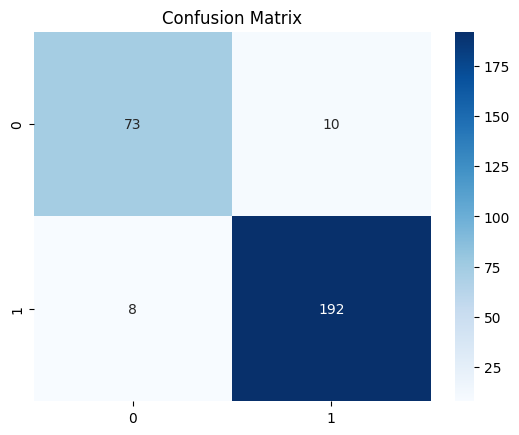

ROC-AUC: 0.9768072289156626


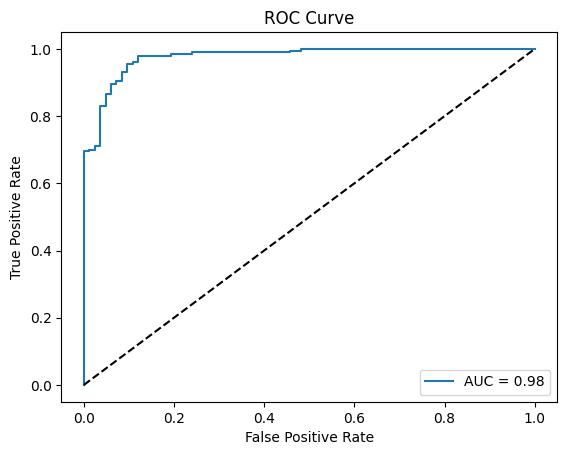

(array([1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
        1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0,
        0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
        0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
        1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0,
        0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
        1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
        1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1,
        0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
        0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1,
        1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1]),
 array([1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0

In [30]:
resnet101 = models.resnet101(pretrained=True)
for param in resnet101.parameters():
    param.requires_grad = False

for param in resnet101.layer4.parameters():
    param.requires_grad = True

resnet101.fc = nn.Linear(resnet101.fc.in_features, 2)

print("Training ResNet-101...")
resnet101 = train_model(resnet101, train_loader, test_loader, epochs=20)

print("Evaluating ResNet-101...")
evaluate_model(resnet101, test_loader)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training DenseNet-121...
Epoch [1/20] Loss: 0.3883 Train Acc: 0.8271
Epoch [2/20] Loss: 0.3016 Train Acc: 0.8528
Epoch [3/20] Loss: 0.2695 Train Acc: 0.8635
Epoch [4/20] Loss: 0.2656 Train Acc: 0.8652
Epoch [5/20] Loss: 0.2813 Train Acc: 0.8528
Epoch [6/20] Loss: 0.2503 Train Acc: 0.8661
Epoch [7/20] Loss: 0.2448 Train Acc: 0.8785
Epoch [8/20] Loss: 0.2476 Train Acc: 0.8723
Epoch [9/20] Loss: 0.2407 Train Acc: 0.8741
Epoch [10/20] Loss: 0.2532 Train Acc: 0.8803
Epoch [11/20] Loss: 0.2267 Train Acc: 0.8812
Epoch [12/20] Loss: 0.2158 Train Acc: 0.8883
Epoch [13/20] Loss: 0.2241 Train Acc: 0.8901
Epoch [14/20] Loss: 0.2108 Train Acc: 0.9025
Epoch [15/20] Loss: 0.2077 Train Acc: 0.9034
Epoch [16/20] Loss: 0.2249 Train Acc: 0.8927
Epoch [17/20] Loss: 0.2019 Train Acc: 0.9051
Epoch [18/20] Loss: 0.2012 Train Acc: 0.9149
Epoch [19/20] Loss: 0.2006 Train Acc: 0.9007
Epoch [20/20] Loss: 0.1922 Train Acc: 0.9105
Evaluating DenseNet-121...
              precision    recall  f1-score   support

  

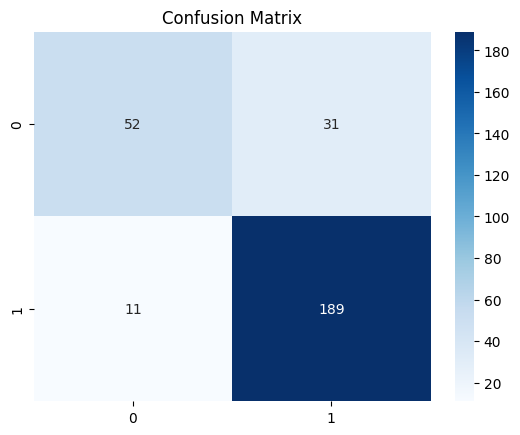

ROC-AUC: 0.9212048192771084


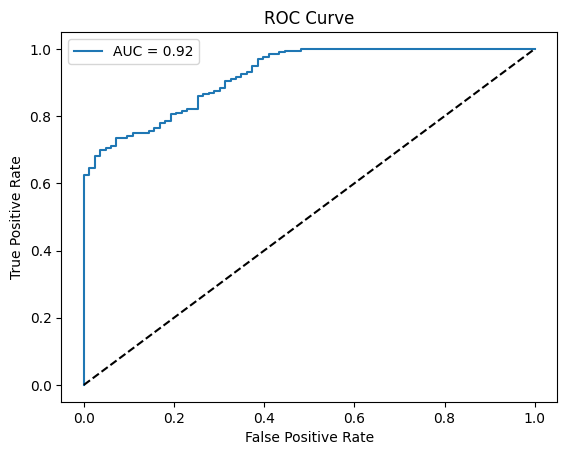

(array([1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
        1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0,
        0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
        0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
        1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0,
        0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
        1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
        1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1,
        0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
        0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1,
        1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1]),
 array([1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0

In [36]:
densenet121 = models.densenet121(pretrained=True)
for param in densenet121.parameters():
    param.requires_grad = False

for param in densenet121.features.denseblock4.parameters():
    param.requires_grad = True

for param in densenet121.features.norm5.parameters():
    param.requires_grad = True

densenet121.classifier = nn.Linear(densenet121.classifier.in_features, 2)

print("Training DenseNet-121...")
densenet121 = train_model(densenet121, train_loader, test_loader, epochs=20)

print("Evaluating DenseNet-121...")
evaluate_model(densenet121, test_loader)

Training EfficientNet-B3...
Epoch [1/20] Loss: 0.4755 Train Acc: 0.7970
Epoch [2/20] Loss: 0.3214 Train Acc: 0.8546
Epoch [3/20] Loss: 0.2796 Train Acc: 0.8706
Epoch [4/20] Loss: 0.2708 Train Acc: 0.8466
Epoch [5/20] Loss: 0.2638 Train Acc: 0.8777
Epoch [6/20] Loss: 0.2556 Train Acc: 0.8706
Epoch [7/20] Loss: 0.2410 Train Acc: 0.8830
Epoch [8/20] Loss: 0.2446 Train Acc: 0.8759
Epoch [9/20] Loss: 0.2440 Train Acc: 0.8785
Epoch [10/20] Loss: 0.2333 Train Acc: 0.8750
Epoch [11/20] Loss: 0.2292 Train Acc: 0.8936
Epoch [12/20] Loss: 0.2230 Train Acc: 0.8918
Epoch [13/20] Loss: 0.2410 Train Acc: 0.9016
Epoch [14/20] Loss: 0.2345 Train Acc: 0.8732
Epoch [15/20] Loss: 0.2203 Train Acc: 0.8883
Epoch [16/20] Loss: 0.2237 Train Acc: 0.8883
Epoch [17/20] Loss: 0.2187 Train Acc: 0.8918
Epoch [18/20] Loss: 0.2064 Train Acc: 0.8998
Epoch [19/20] Loss: 0.2149 Train Acc: 0.8874
Epoch [20/20] Loss: 0.2203 Train Acc: 0.8865
Evaluating EfficientNet-B3...
              precision    recall  f1-score   suppo

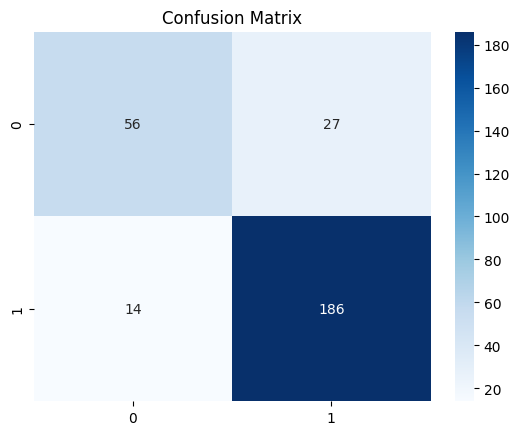

ROC-AUC: 0.9451807228915663


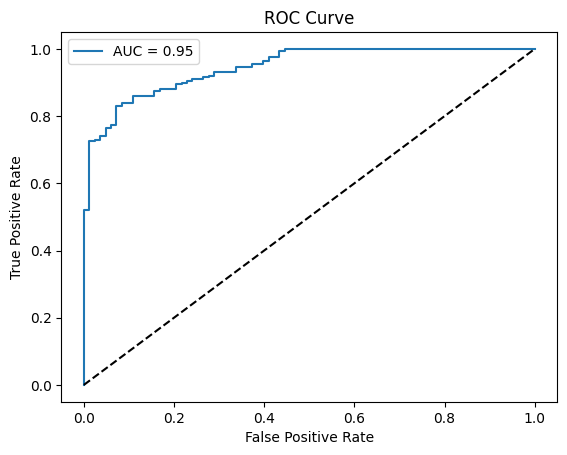

(array([1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
        1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0,
        0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
        0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
        1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0,
        0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
        1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
        1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1,
        0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
        0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1,
        1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1]),
 array([1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0

In [33]:
efficientnet_b3 = timm.create_model("efficientnet_b3", pretrained=True)
for param in efficientnet_b3.parameters():
    param.requires_grad = False

for param in efficientnet_b3.blocks[-1].parameters():
    param.requires_grad = True

efficientnet_b3.classifier = nn.Linear(efficientnet_b3.classifier.in_features, 2)

print("Training EfficientNet-B3...")
efficientnet_b3 = train_model(efficientnet_b3, train_loader, test_loader, epochs=20)

print("Evaluating EfficientNet-B3...")
evaluate_model(efficientnet_b3, test_loader)

Training EfficientNet-B4...
Epoch [1/20] Loss: 0.5504 Train Acc: 0.7340
Epoch [2/20] Loss: 0.3897 Train Acc: 0.8537
Epoch [3/20] Loss: 0.3214 Train Acc: 0.8608
Epoch [4/20] Loss: 0.2965 Train Acc: 0.8617
Epoch [5/20] Loss: 0.2799 Train Acc: 0.8723
Epoch [6/20] Loss: 0.2775 Train Acc: 0.8599
Epoch [7/20] Loss: 0.2792 Train Acc: 0.8608
Epoch [8/20] Loss: 0.2602 Train Acc: 0.8715
Epoch [9/20] Loss: 0.2574 Train Acc: 0.8777
Epoch [10/20] Loss: 0.2731 Train Acc: 0.8564
Epoch [11/20] Loss: 0.2549 Train Acc: 0.8652
Epoch [12/20] Loss: 0.2703 Train Acc: 0.8608
Epoch [13/20] Loss: 0.2502 Train Acc: 0.8723
Epoch [14/20] Loss: 0.2589 Train Acc: 0.8750
Epoch [15/20] Loss: 0.2601 Train Acc: 0.8626
Epoch [16/20] Loss: 0.2511 Train Acc: 0.8768
Epoch [17/20] Loss: 0.2439 Train Acc: 0.8785
Epoch [18/20] Loss: 0.2524 Train Acc: 0.8590
Epoch [19/20] Loss: 0.2429 Train Acc: 0.8723
Epoch [20/20] Loss: 0.2566 Train Acc: 0.8697
Evaluating EfficientNet-B4...
              precision    recall  f1-score   suppo

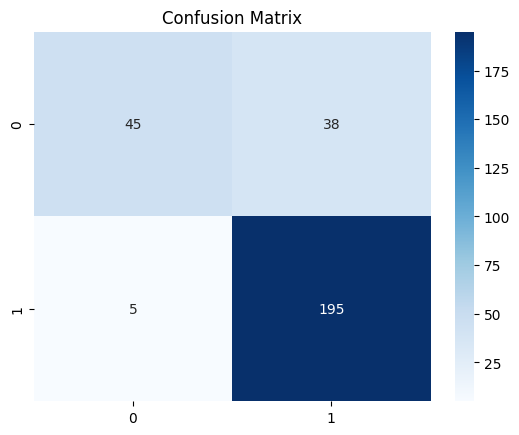

ROC-AUC: 0.9336144578313254


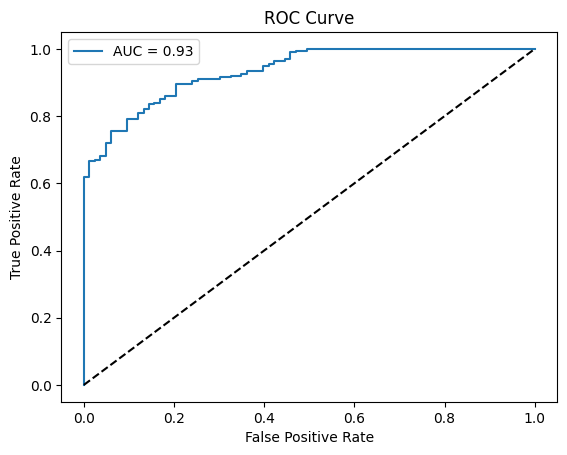

(array([1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
        1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0,
        0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
        0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
        1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0,
        0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
        1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
        1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1,
        0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
        0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1,
        1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1]),
 array([1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0

In [35]:
efficientnet_b4 = timm.create_model("efficientnet_b4", pretrained=True)

# Freeze layers
for param in efficientnet_b4.parameters():
    param.requires_grad = False

# Unfreeze last block
for param in efficientnet_b4.blocks[-1].parameters():
    param.requires_grad = True

# Replace classifier
efficientnet_b4.classifier = nn.Linear(
    efficientnet_b4.classifier.in_features, 2
)

efficientnet_b4 = efficientnet_b4.to(device)

print("Training EfficientNet-B4...")
efficientnet_b4 = train_model(efficientnet_b4, train_loader, test_loader, epochs=20)

print("Evaluating EfficientNet-B4...")
evaluate_model(efficientnet_b4, test_loader)

In [37]:
from sklearn.metrics import roc_curve, auc

def evaluate_with_prob(model, loader):

    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)[:,1]

            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    return all_labels, all_preds, all_probs, fpr, tpr, roc_auc

In [38]:
res_labels, res_preds, res_probs, res_fpr, res_tpr, res_auc = evaluate_with_prob(resnet101, test_loader)

den_labels, den_preds, den_probs, den_fpr, den_tpr, den_auc = evaluate_with_prob(densenet121, test_loader)

eff_labels, eff_preds, eff_probs, eff_fpr, eff_tpr, eff_auc = evaluate_with_prob(efficientnet_b3, test_loader)

effb4_labels, effb4_preds, effb4_probs, effb4_fpr, effb4_tpr, effb4_auc = evaluate_with_prob(efficientnet_b4, test_loader)

In [39]:
res_labels = np.array(res_labels)
res_preds = np.array(res_preds)

den_labels = np.array(den_labels)
den_preds = np.array(den_preds)

eff_labels = np.array(eff_labels)
eff_preds = np.array(eff_preds)

effb4_labels = np.array(effb4_labels)
effb4_preds = np.array(effb4_preds)

In [40]:
print("ResNet correct:", np.sum(res_labels == res_preds))
print("DenseNet correct:", np.sum(den_labels == den_preds))
print("EfficientNet-B3 correct:", np.sum(eff_labels == eff_preds))
print("EfficientNet-B4 correct:", np.sum(effb4_labels == effb4_preds))

ResNet correct: 262
DenseNet correct: 244
EfficientNet-B3 correct: 242
EfficientNet-B4 correct: 239


In [41]:
print(res_labels.shape, res_preds.shape)

(283,) (283,)


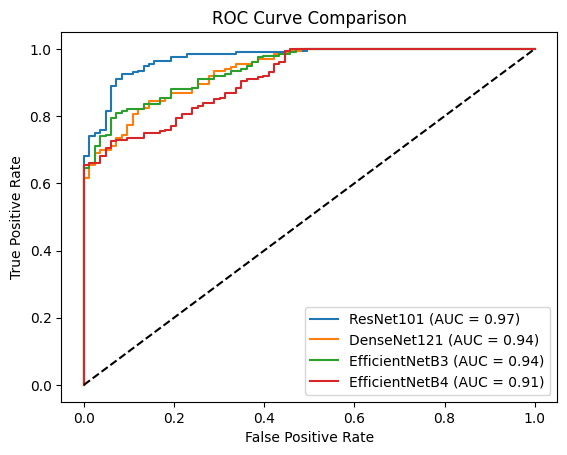

In [42]:
plt.figure()

plt.plot(res_fpr, res_tpr, label=f"ResNet101 (AUC = {res_auc:.2f})")
plt.plot(den_fpr, den_tpr, label=f"DenseNet121 (AUC = {den_auc:.2f})")
plt.plot(eff_fpr, eff_tpr, label=f"EfficientNetB3 (AUC = {eff_auc:.2f})")
plt.plot(effb4_fpr, effb4_tpr, label=f"EfficientNetB4 (AUC = {effb4_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [43]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def get_metrics(labels, preds):
    return {
        "Accuracy": accuracy_score(labels, preds),
        "Precision": precision_score(labels, preds),
        "Recall": recall_score(labels, preds),
        "F1": f1_score(labels, preds)
    }

res_metrics = get_metrics(res_labels, res_preds)
den_metrics = get_metrics(den_labels, den_preds)
eff_metrics = get_metrics(eff_labels, eff_preds)
effb4_metrics = get_metrics(effb4_labels, effb4_preds)

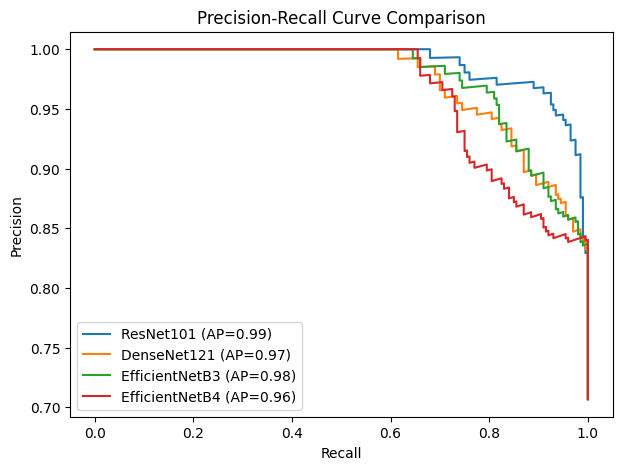

In [45]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(7,5))

for labels, probs, name in [
    (res_labels, res_probs, "ResNet101"),
    (den_labels, den_probs, "DenseNet121"),
    (eff_labels, eff_probs, "EfficientNetB3"),
    (effb4_labels, effb4_probs, "EfficientNetB4")
]:

    precision, recall, _ = precision_recall_curve(labels, probs)
    ap = average_precision_score(labels, probs)

    plt.plot(recall, precision, label=f"{name} (AP={ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

In [46]:
import matplotlib.pyplot as plt

def plot_metrics(metrics, model_name):

    names = list(metrics.keys())
    values = list(metrics.values())

    plt.figure(figsize=(6,4))
    bars = plt.bar(names, values)

    plt.title(f"{model_name} Evaluation Metrics")
    plt.ylabel("Score")
    plt.ylim(0,1)

    for bar in bars:
        y = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 y + 0.01,
                 f"{y:.2f}",
                 ha='center')

    plt.show()

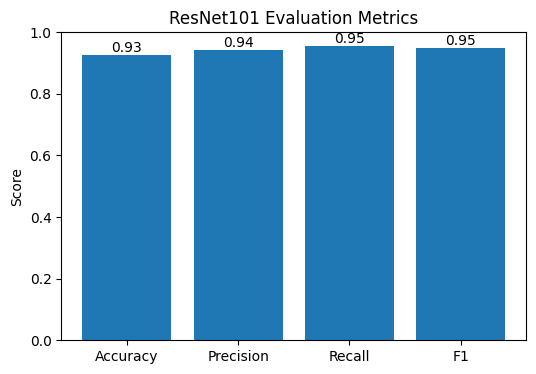

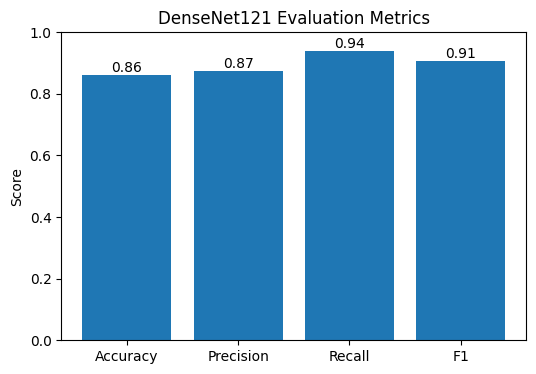

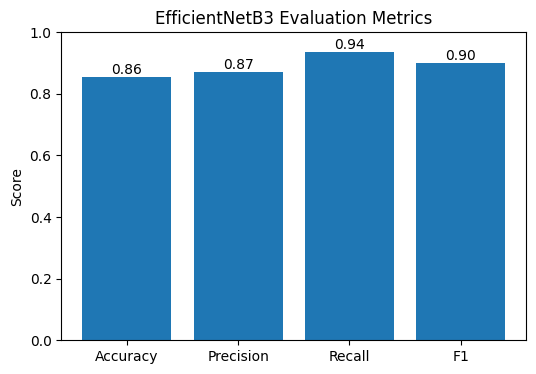

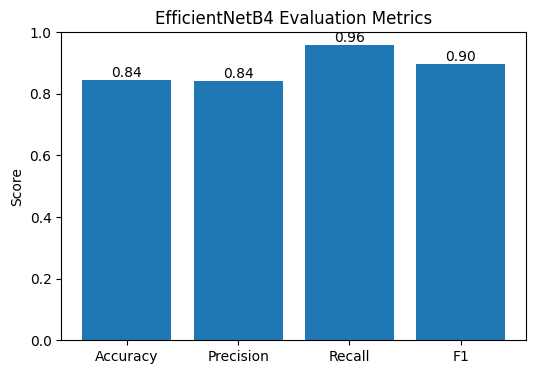

In [47]:
plot_metrics(res_metrics, "ResNet101")
plot_metrics(den_metrics, "DenseNet121")
plot_metrics(eff_metrics, "EfficientNetB3")
plot_metrics(effb4_metrics, "EfficientNetB4")

In [48]:
import pandas as pd

df = pd.DataFrame(
    [res_metrics, den_metrics, eff_metrics,effb4_metrics],
    index=["ResNet101", "DenseNet121", "EfficientNetB3","EfficientNetB4"]
)

print(df)

                Accuracy  Precision  Recall        F1
ResNet101       0.925795   0.940887   0.955  0.947891
DenseNet121     0.862191   0.874419   0.940  0.906024
EfficientNetB3  0.855124   0.869767   0.935  0.901205
EfficientNetB4  0.844523   0.842105   0.960  0.897196


In [49]:
res_metrics["ROC-AUC"] = res_auc
den_metrics["ROC-AUC"] = den_auc
eff_metrics["ROC-AUC"] = eff_auc
effb4_metrics["ROC-AUC"] = effb4_auc

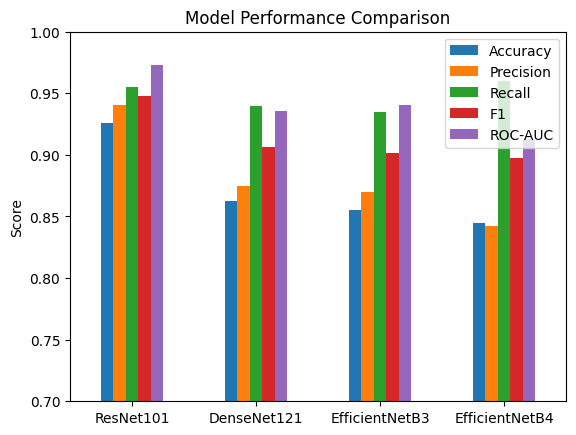

In [50]:
import pandas as pd

df = pd.DataFrame([res_metrics, den_metrics, eff_metrics,effb4_metrics],
                  index=["ResNet101", "DenseNet121", "EfficientNetB3","EfficientNetB4"])

df.plot(kind='bar')
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0.7, 1.0)
plt.xticks(rotation=0)
plt.show()

In [51]:
import pandas as pd

metrics_df = pd.DataFrame(
    [res_metrics, den_metrics, eff_metrics,effb4_metrics],
    index=["ResNet101", "DenseNet121", "EfficientNetB3","EfficientNetB4"]
)

print(metrics_df)

                Accuracy  Precision  Recall        F1   ROC-AUC
ResNet101       0.925795   0.940887   0.955  0.947891  0.972771
DenseNet121     0.862191   0.874419   0.940  0.906024  0.935904
EfficientNetB3  0.855124   0.869767   0.935  0.901205  0.940843
EfficientNetB4  0.844523   0.842105   0.960  0.897196  0.912711


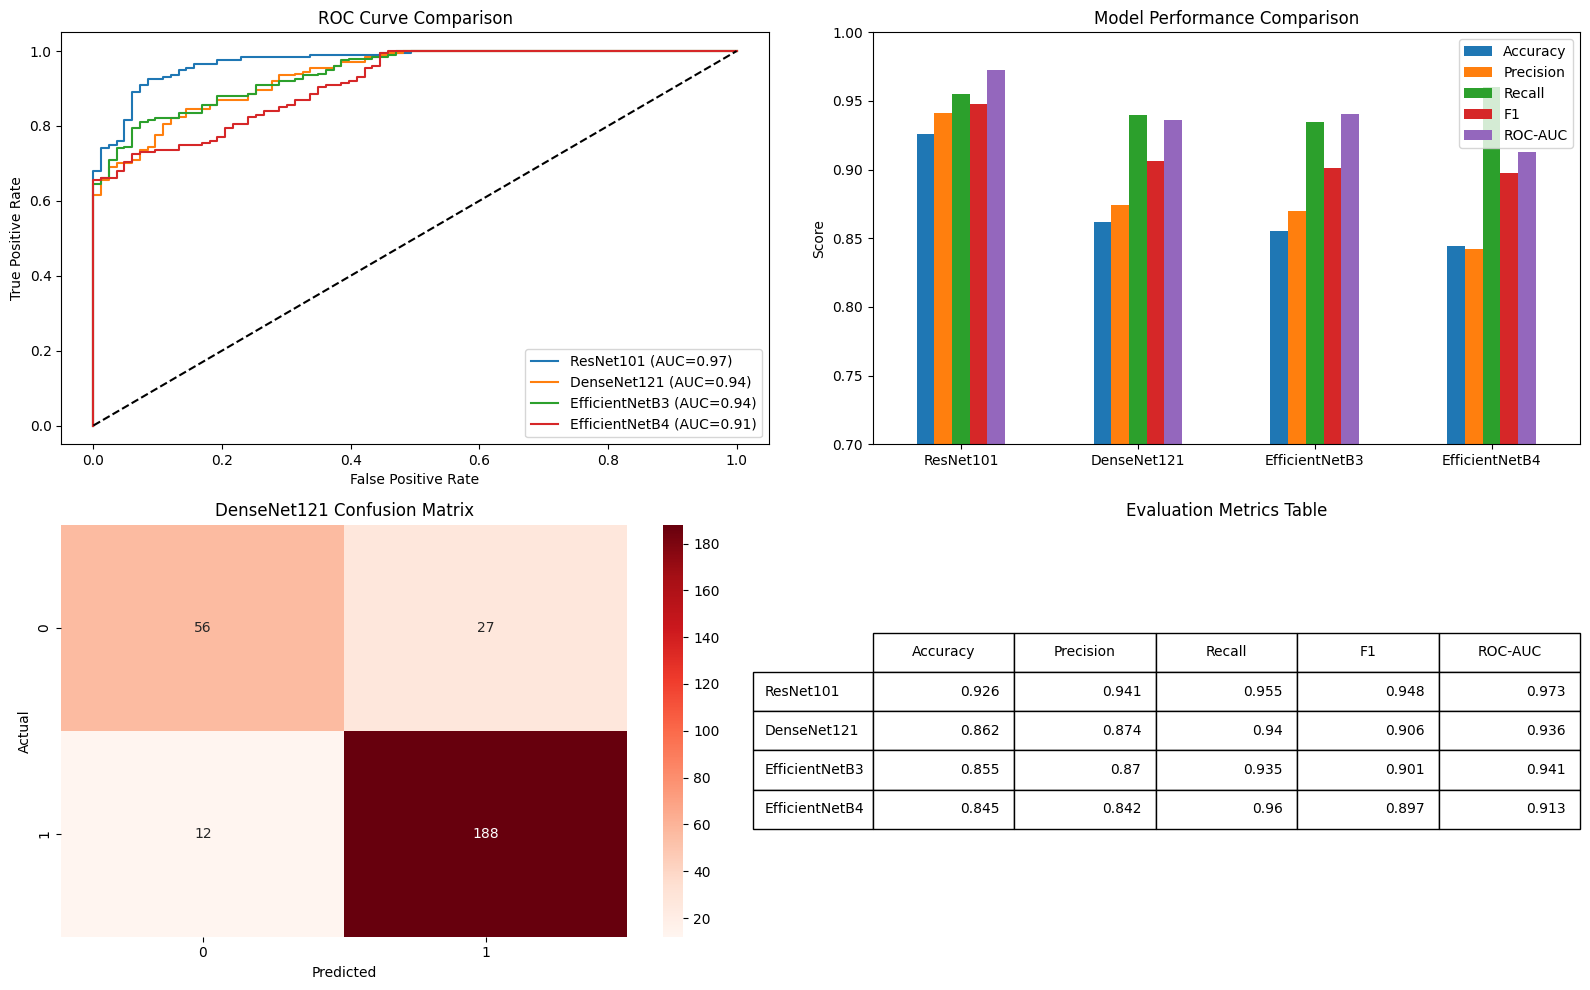

In [52]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig = plt.figure(figsize=(16,10))

# -------------------------------
# 1️⃣ ROC Curve Comparison
# -------------------------------
ax1 = plt.subplot(2,2,1)

plt.plot(res_fpr, res_tpr, label=f"ResNet101 (AUC={res_auc:.2f})")
plt.plot(den_fpr, den_tpr, label=f"DenseNet121 (AUC={den_auc:.2f})")
plt.plot(eff_fpr, eff_tpr, label=f"EfficientNetB3 (AUC={eff_auc:.2f})")
plt.plot(effb4_fpr, effb4_tpr, label=f"EfficientNetB4 (AUC={effb4_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

# -------------------------------
# 2️⃣ Metrics Comparison
# -------------------------------
ax2 = plt.subplot(2,2,2)

metrics_df.plot(kind='bar', ax=ax2)
ax2.set_title("Model Performance Comparison")
ax2.set_ylabel("Score")
ax2.set_ylim(0.7,1.0)
ax2.set_xticklabels(metrics_df.index, rotation=0)

# -------------------------------
# 3️⃣ Confusion Matrix (Best Model)
# -------------------------------
ax3 = plt.subplot(2,2,3)

cm = confusion_matrix(den_labels, den_preds)  # DenseNet as best model
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", ax=ax3)

ax3.set_title("DenseNet121 Confusion Matrix")
ax3.set_xlabel("Predicted")
ax3.set_ylabel("Actual")

# -------------------------------
# 4️⃣ Metrics Table
# -------------------------------
ax4 = plt.subplot(2,2,4)
ax4.axis('off')

table = ax4.table(
    cellText=metrics_df.round(3).values,
    colLabels=metrics_df.columns,
    rowLabels=metrics_df.index,
    loc='center'
)

table.scale(1,2)
ax4.set_title("Evaluation Metrics Table")

plt.tight_layout()
plt.show()

In [53]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_image):

        self.model.eval()
        output = self.model(input_image)
        class_idx = torch.argmax(output)

        self.model.zero_grad()
        output[0, class_idx].backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = torch.mean(gradients, dim=(1,2))

        cam = torch.zeros(activations.shape[1:]).to(device)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / cam.max()

        return cam.detach().cpu().numpy()

In [56]:
target_layer = resnet101.layer4[-1]
gradcam = GradCAM(resnet101, target_layer)

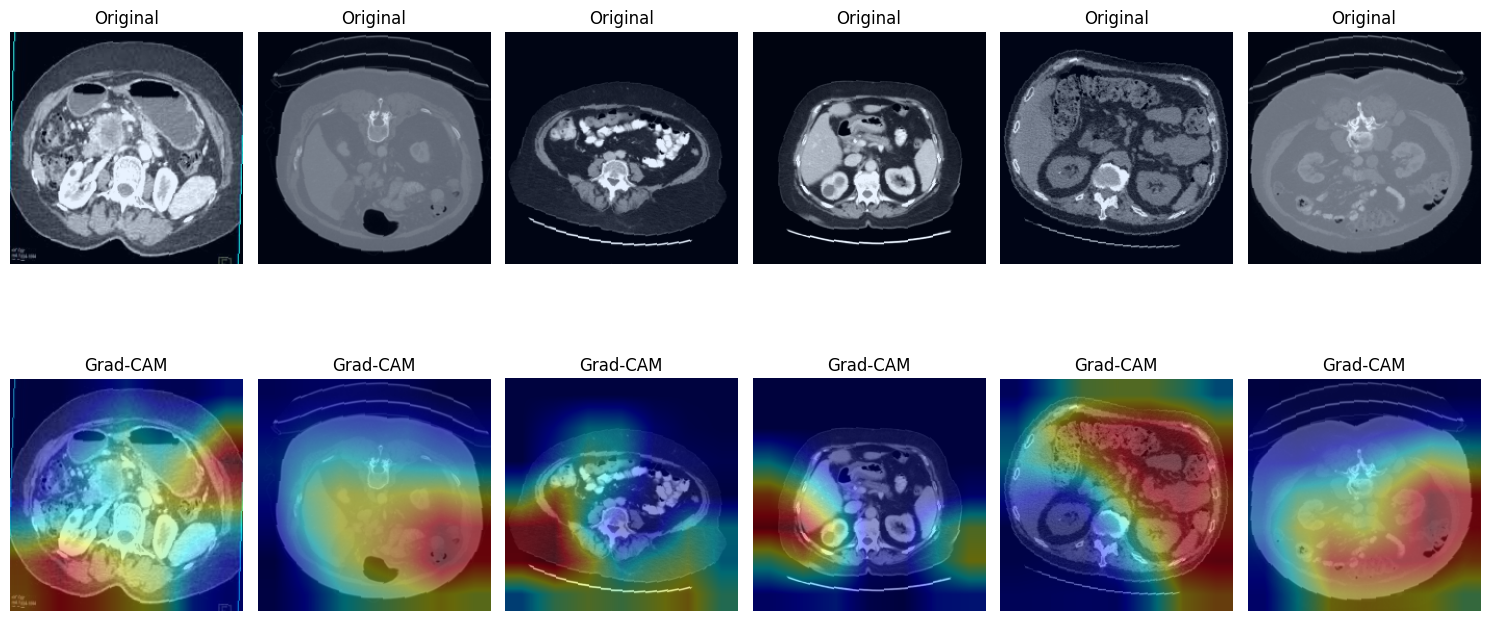

In [57]:
import random
import cv2
import matplotlib.pyplot as plt
import types
import torch.nn.functional as F
from torch import Tensor

target_layer = resnet101.layer4[-1]
gradcam = GradCAM(resnet101, target_layer)

indices = random.sample(range(len(test_dataset)), 6)

plt.figure(figsize=(15,8))

for i, idx in enumerate(indices):

    img, label = test_dataset[idx]
    input_tensor = img.unsqueeze(0).to(device)

    cam = gradcam.generate(input_tensor)

    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    cam = cv2.resize(cam, (224,224))

    heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    original = img.permute(1,2,0).cpu().numpy()
    original = (original - original.min())/(original.max()-original.min())
    original = np.uint8(255*original)

    overlay = cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)

    plt.subplot(2,6,i+1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2,6,i+7)
    plt.imshow(overlay)
    plt.title("Grad-CAM")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [58]:
class GradCAMPlusPlus:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_image):

        self.model.eval()

        output = self.model(input_image)
        class_idx = torch.argmax(output)

        self.model.zero_grad()
        output[0, class_idx].backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        grad_2 = gradients ** 2
        grad_3 = gradients ** 3

        sum_activations = torch.sum(activations, dim=(1,2), keepdim=True)

        alpha = grad_2 / (2 * grad_2 + sum_activations * grad_3 + 1e-8)

        weights = torch.sum(alpha * torch.relu(gradients), dim=(1,2))

        cam = torch.zeros(activations.shape[1:], device=activations.device)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.detach().cpu().numpy()

In [59]:
target_layer = resnet101.layer4[-1]
gradcam = GradCAMPlusPlus(resnet101, target_layer)

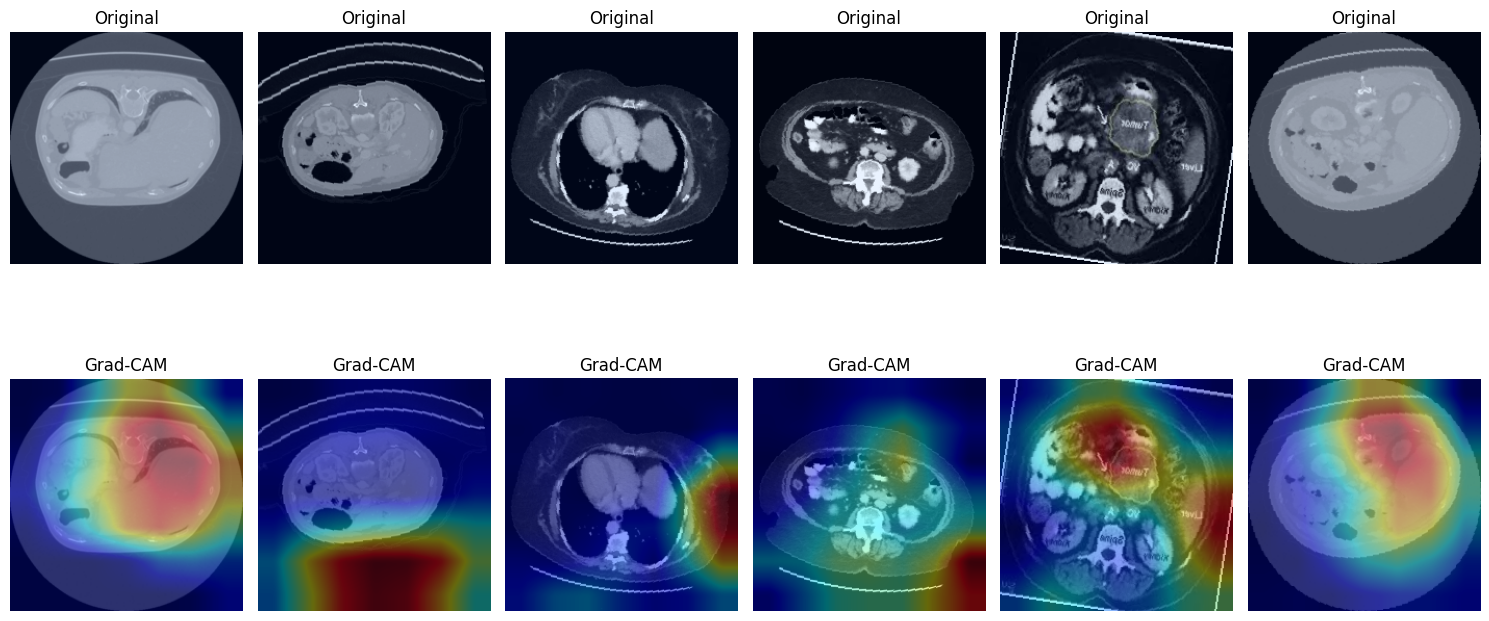

In [60]:
import random
import cv2
import matplotlib.pyplot as plt
import types
import torch.nn.functional as F
from torch import Tensor

target_layer = resnet101.layer4[-1]
gradcam = GradCAM(resnet101, target_layer)

indices = random.sample(range(len(test_dataset)), 6)

plt.figure(figsize=(15,8))

for i, idx in enumerate(indices):

    img, label = test_dataset[idx]
    input_tensor = img.unsqueeze(0).to(device)

    cam = gradcam.generate(input_tensor)

    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    cam = cv2.resize(cam, (224,224))
    cam = cv2.GaussianBlur(cam, (11,11), 0)

    heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    original = img.permute(1,2,0).cpu().numpy()
    original = (original - original.min())/(original.max()-original.min())
    original = np.uint8(255*original)

    overlay = cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)

    plt.subplot(2,6,i+1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2,6,i+7)
    plt.imshow(overlay)
    plt.title("Grad-CAM")
    plt.axis("off")

plt.tight_layout()
plt.show()